In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

df_video = pd.read_csv(r"D:\tn-da22tta-110122034-chaugiabao-youtube-dw-trending\src\analysis\data\cleaned_video.csv")
pd.set_option('display.max_columns', None)
print(f"Data shape before: {df_video.shape}")

Data shape before: (1171067, 45)


In [2]:
features = [
    'subscriber_count',
    'view_count',
    'video_count',
    'duration_seconds',
    'like_rate',
    'comment_rate',
    'topic',
    'country_region',
    'publish_hour'
]

X = df_video[features].copy()

# Log transform
for col in [
    'subscriber_count',
    'view_count',
    'video_count',
    'duration_seconds'
]:
    X[col] = np.log1p(X[col])

y = df_video['is_trending']

In [3]:
categorical_cols = [
    'topic',
    'country_region'
]

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(scale_pos_weight)

3.283539847286361


In [6]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [7]:
y_pred = xgb_model.predict(X_test)

y_prob = xgb_model.predict_proba(X_test)[:, 1]

In [8]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.9368
Precision: 0.8006
Recall   : 0.9713
F1-score : 0.8778
ROC-AUC  : 0.9897


In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.99      0.93      0.96    179536
        True       0.80      0.97      0.88     54678

    accuracy                           0.94    234214
   macro avg       0.90      0.95      0.92    234214
weighted avg       0.95      0.94      0.94    234214



In [10]:
print(confusion_matrix(y_test, y_pred))

[[166311  13225]
 [  1568  53110]]


In [11]:
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

            Feature  Importance
3  duration_seconds    0.415916
6             topic    0.292445
7    country_region    0.098380
5      comment_rate    0.050618
4         like_rate    0.039281
1        view_count    0.032988
0  subscriber_count    0.032814
2       video_count    0.022138
8      publish_hour    0.015420


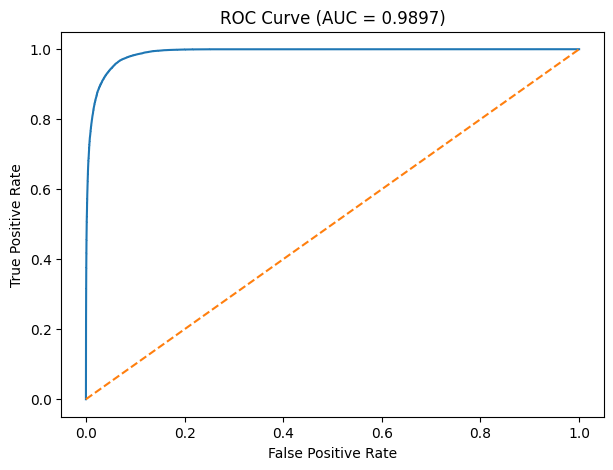

In [12]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")

plt.show()

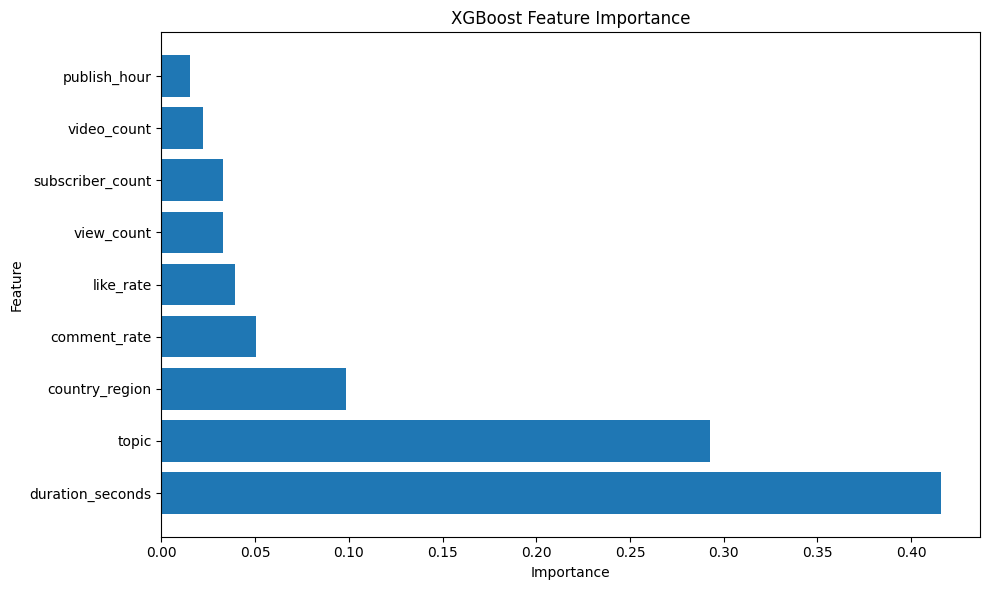

In [13]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance')

plt.tight_layout()
plt.show()

In [14]:
xgb_model.save_model("xgb_trending_model_v2.json")

In [15]:
print(features)

['subscriber_count', 'view_count', 'video_count', 'duration_seconds', 'like_rate', 'comment_rate', 'topic', 'country_region', 'publish_hour']
